# Section énoncé

### Read "AROME_ARPEGE_SIRTA_Oct2015_Sep2019.txt"

### import modules

In [151]:
import numpy as np
import datetime as dt
import pandas as pd
import glob
from matplotlib import pyplot as plt

# Style of figures
plt.style.use('seaborn-v0_8')
# Size of figures
plt.rcParams['figure.figsize'] = 10, 7

### Define a function to read the file 

In [152]:
COL_NAMES = [
    'date','SZA','SAA','DIRECT', 'DIFFUSE', 'GLOBAL', 'cGLOBAL', 
    'GLO_ARO1_J', 'GLO_ARO2_J', 'GLO_ARP_J', 'GLO_ARO1_J1', 'GLO_ARO2_J1', 'GLO_ARP_J1', 
    'mT2', 'T2_ARO1_J','T2_ARO2_J','T2_ARP_J','T2_ARO1_J1','T2_ARO2_J1','T2_ARP_J1', 
    'mRH','RH_ARO1_J','RH_ARO2_J','RH_ARP_J','RH_ARO1_J1','RH_ARO2_J1','RH_ARP_J1', 
]


def read_aa(files):

    for n, f in enumerate(files):
        tmp = pd.io.parsers.read_table(
            f,
            comment='#',
            sep=',',
            parse_dates=[0],
            date_parser=lambda s: dt.datetime.strptime(s, "%Y-%m-%d %H:%M:%S"),
            names=COL_NAMES,
            index_col='date',
            #na_values = ["-999", "-999.99", "-99.9"],
        )
        if n == 0:
            data = tmp
        else:
            data = pd.concat([df, tmp])

    return data

### Read the file in a data frame

In [153]:
files = glob.glob('AROME_ARPEGE_SIRTA_Oct2015_Sep2019.txt')
data = read_aa(files)

/var/folders/xf/zzxt_7gs0f59w4vpftk6lq780000gn/T/ipykernel_2284/55827281.py:12: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  tmp = pd.io.parsers.read_table(


### call the columns in the data frame

In [154]:
data.columns

Index(['SZA', 'SAA', 'DIRECT', 'DIFFUSE', 'GLOBAL', 'cGLOBAL', 'GLO_ARO1_J',
       'GLO_ARO2_J', 'GLO_ARP_J', 'GLO_ARO1_J1', 'GLO_ARO2_J1', 'GLO_ARP_J1',
       'mT2', 'T2_ARO1_J', 'T2_ARO2_J', 'T2_ARP_J', 'T2_ARO1_J1', 'T2_ARO2_J1',
       'T2_ARP_J1', 'mRH', 'RH_ARO1_J', 'RH_ARO2_J', 'RH_ARP_J', 'RH_ARO1_J1',
       'RH_ARO2_J1', 'RH_ARP_J1'],
      dtype='object')

### Simple plots

<Axes: xlabel='date'>

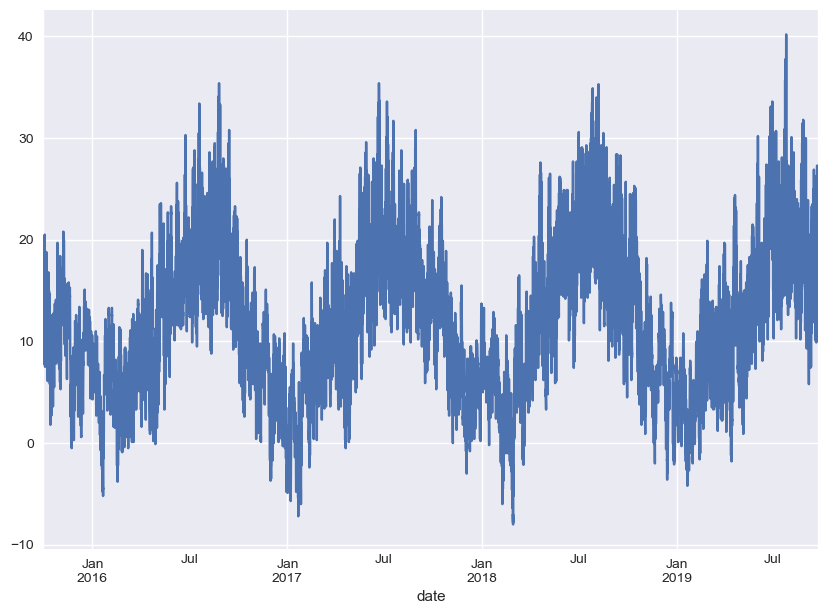

In [155]:
data.mT2.plot()

<Axes: xlabel='date'>

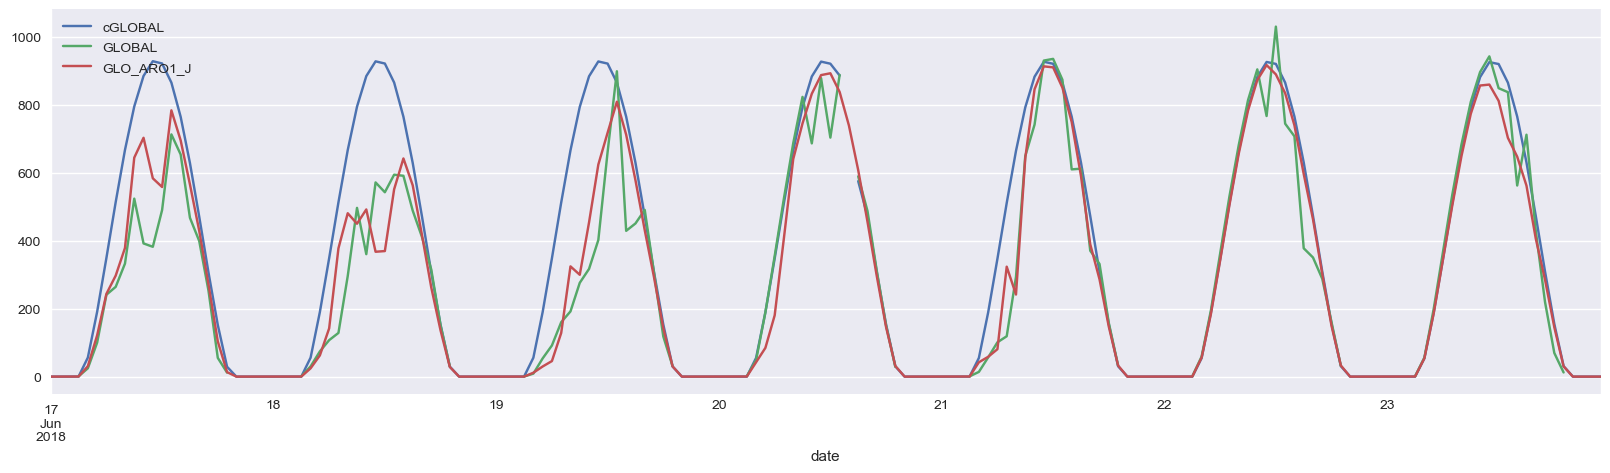

In [156]:
fig,ax = plt.subplots(figsize=(20,5))
data['20180617':'20180623'][['cGLOBAL','GLOBAL','GLO_ARO1_J']].plot(ax=ax)

### Resample data in daily sums 

In [157]:
data1D = data.resample('1D').sum()

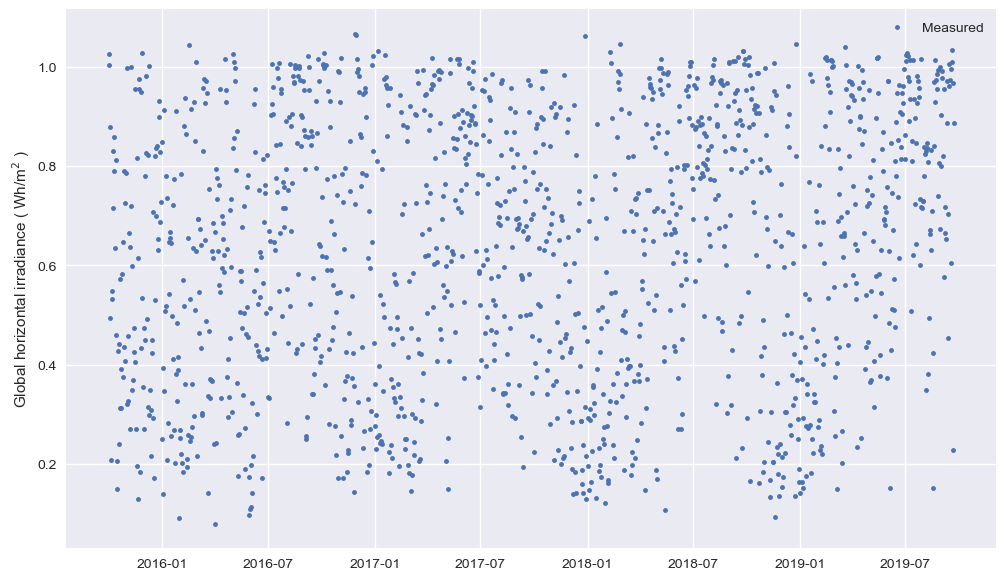

In [158]:
ax = plt.figure( figsize = (12,7) )
plt.plot(data1D.index,data1D.GLOBAL/data1D.cGLOBAL,linestyle='none',marker='.')
plt.ylabel('Global horizontal irradiance ( Wh/m$^2$ )')
plt.legend(['Measured'])

Text(0.5, 0, 'Measured daily irradiation ( Wh/m$^2$ )')

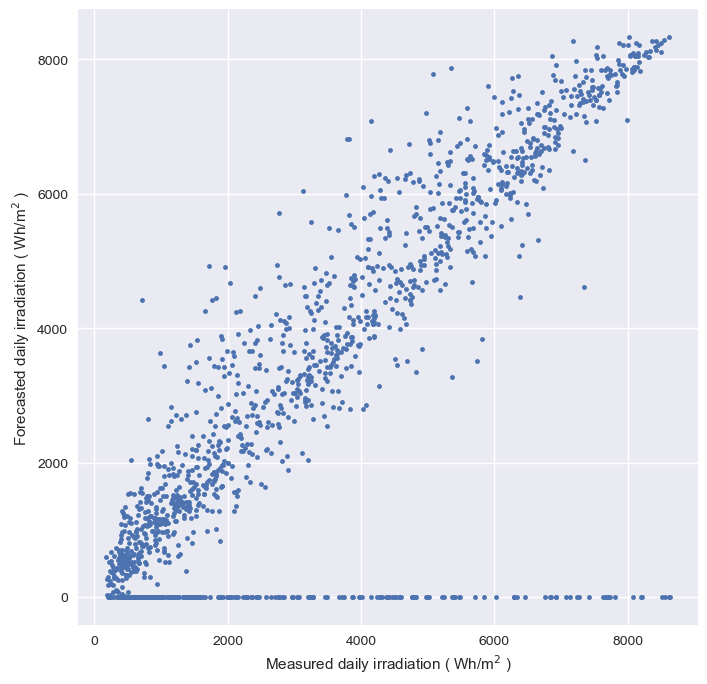

In [159]:
ax=plt.figure(figsize=(8,8))
plt.plot(data1D.GLOBAL,data1D.GLO_ARO1_J,linestyle='none',marker='.')

plt.ylabel('Forecasted daily irradiation ( Wh/m$^2$ )')
plt.xlabel('Measured daily irradiation ( Wh/m$^2$ )')

### eliminate zeros

In [160]:
data1D[data1D==0] = np.nan

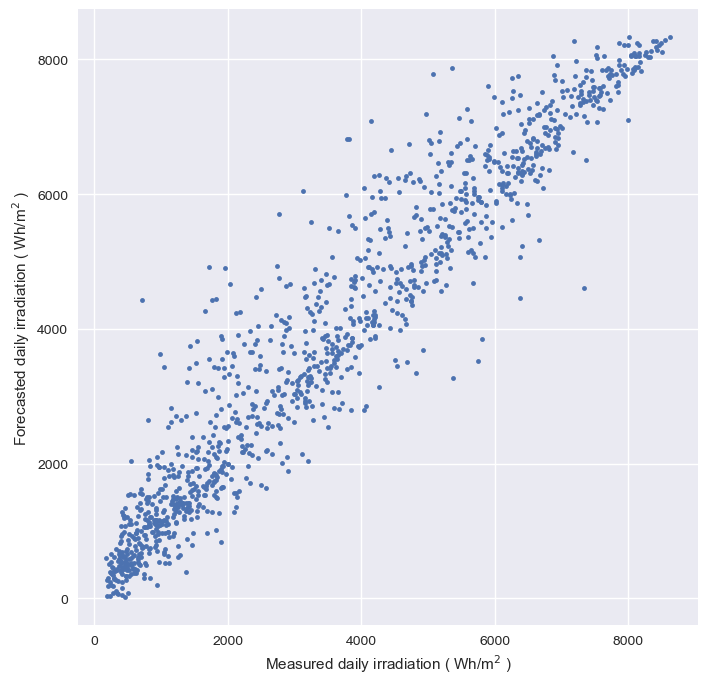

In [161]:
fig,ax = plt.subplots(figsize = (8,8))
ax.plot(data1D.GLOBAL,data1D.GLO_ARO1_J,linestyle='none',marker='.')

ax.set_ylabel('Forecasted daily irradiation ( Wh/m$^2$ )')
ax.set_xlabel('Measured daily irradiation ( Wh/m$^2$ )')

plt.savefig('test.png')

### Read PV df file

In [162]:
dataPV = pd.read_csv('Data_PV1_IVparams_radflux_meteo_ms700_gps_aeronet_2015_2020.csv',
                    header=0,  # la ligne contenant le titre des colonnes
    infer_datetime_format=True,  # on le laisse tenter de décoder les dates seules
    parse_dates=['Date and time (UTC)'],  # on indique les colonnes contenant des dates
    index_col=['Date and time (UTC)'],  # la colonne jouant le role "d'index", la colonne principale
)

/var/folders/xf/zzxt_7gs0f59w4vpftk6lq780000gn/T/ipykernel_2284/2079233336.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dataPV = pd.read_csv('Data_PV1_IVparams_radflux_meteo_ms700_gps_aeronet_2015_2020.csv',


In [163]:
dataPV

,Pmax_FranceWatts,Imax_FranceWatts,Vmax_FranceWatts,Isc_FranceWatts,Voc_FranceWatts,FF_FranceWatts,Tp_FranceWatts,Pmax_Sharp,Imax_Sharp,Vmax_Sharp,...,I1042,I1043,I1044,I1045,I1046,I1047,I1048,I1049,I1050,AOD700
Date and time (UTC),,,,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.049
2015-01-01 00:10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.049
2015-01-01 00:20:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.049
2015-01-01 00:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.049
2015-01-01 00:40:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.049
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-07-18 06:20:00,25.858,0.883,29.209,0.950,34.310,0.795,21.582,NaN,NaN,NaN,...,93.647,93.372,93.025,92.677,92.339,92.044,91.746,91.449,91.038,0.066
2015-07-18 06:30:00,39.614,1.289,30.582,1.518,34.769,0.758,23.505,NaN,NaN,NaN,...,128.232,127.719,127.142,126.569,126.067,125.841,125.617,125.391,124.754,0.066
2015-07-18 06:40:00,52.292,1.729,30.252,2.025,34.906,0.740,26.619,NaN,NaN,NaN,...,255.800,254.851,254.035,253.219,252.428,251.724,251.023,250.318,249.249,0.066


In [164]:
dataPV.columns

Index(['Pmax_FranceWatts', 'Imax_FranceWatts', 'Vmax_FranceWatts',
       'Isc_FranceWatts', 'Voc_FranceWatts', 'FF_FranceWatts',
       'Tp_FranceWatts', 'Pmax_Sharp', 'Imax_Sharp', 'Vmax_Sharp',
       ...
       'I1042', 'I1043', 'I1044', 'I1045', 'I1046', 'I1047', 'I1048', 'I1049',
       'I1050', 'AOD700'],
      dtype='object', length=771)

In [165]:
dataPV10 = dataPV[['Pmax_FranceWatts','Tp_FranceWatts','POA']].resample('1h').mean()

In [166]:
data = pd.merge(data,dataPV10,left_index=True, right_index=True, how='left')

In [167]:
data.columns

Index(['SZA', 'SAA', 'DIRECT', 'DIFFUSE', 'GLOBAL', 'cGLOBAL', 'GLO_ARO1_J',
       'GLO_ARO2_J', 'GLO_ARP_J', 'GLO_ARO1_J1', 'GLO_ARO2_J1', 'GLO_ARP_J1',
       'mT2', 'T2_ARO1_J', 'T2_ARO2_J', 'T2_ARP_J', 'T2_ARO1_J1', 'T2_ARO2_J1',
       'T2_ARP_J1', 'mRH', 'RH_ARO1_J', 'RH_ARO2_J', 'RH_ARP_J', 'RH_ARO1_J1',
       'RH_ARO2_J1', 'RH_ARP_J1', 'Pmax_FranceWatts', 'Tp_FranceWatts', 'POA'],
      dtype='object')

In [168]:
data.to_csv('AROME_ARPEGE_SIRTA_PV_Oct2015_Sep2019.csv',float_format='%.2f',
                        index_label='Date and time (UTC)', na_rep='NaN')

#data.to_excel('Data_ARO_ARP_PV_brut.xlsx',float_format='%.2f',index_label='Date and time (UTC)', na_rep='NaN')

# Section Perso - AROME/ARPEGE

## Nettoyage : données absentes et filtre diurne

In [169]:
df = data[['GLOBAL', 'cGLOBAL', 
           'GLO_ARO1_J','GLO_ARO2_J', 'GLO_ARP_J', 
           'GLO_ARO1_J1', 'GLO_ARO2_J1', 'GLO_ARP_J1']].copy()

df.head()

,GLOBAL,cGLOBAL,GLO_ARO1_J,GLO_ARO2_J,GLO_ARP_J,GLO_ARO1_J1,GLO_ARO2_J1,GLO_ARP_J1
date,,,,,,,,
2015-10-01 00:00:00,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2015-10-01 01:00:00,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2015-10-01 02:00:00,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2015-10-01 03:00:00,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2015-10-01 04:00:00,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [170]:
N = len(df['GLOBAL'])
print(N)
print(np.sum(np.isnan(data['GLOBAL'])),np.sum(np.isnan(data['cGLOBAL'])),np.sum(np.isnan(data['GLO_ARP_J'])),np.sum(np.isnan(data['GLO_ARP_J1'])),
      np.sum(np.isnan(data['GLO_ARO2_J'])),np.sum(np.isnan(data['GLO_ARO1_J1'])),np.sum(np.isnan(data['GLO_ARO2_J1'])))

34896
15830 19 1200 1320 5933 5498 5496


In [171]:
df.dropna(inplace=True)
N = len(df['GLOBAL'])
print(N)
print(np.sum(np.isnan(df['GLOBAL'])),np.sum(np.isnan(df['cGLOBAL'])),np.sum(np.isnan(df['GLO_ARP_J'])),np.sum(np.isnan(df['GLO_ARP_J1'])),
      np.sum(np.isnan(df['GLO_ARO2_J'])),np.sum(np.isnan(df['GLO_ARO1_J1'])),np.sum(np.isnan(df['GLO_ARO2_J1'])))
df.to_excel('Data_ARO_ARP_PV_clean.xlsx',float_format='%.2f',index_label='Date and time (UTC)', na_rep='NaN')

15383
0 0 0 0 0 0 0


In [172]:
df = df[df['GLOBAL']>=1]
N = len(df['GLOBAL'])
print(N)

14983


## Erreurs en fonction du modèle

### MAE sur toute la période en fonction du modèle

In [173]:
#mae_clearsky = np.sum(np.abs(df['cGLOBAL']-df['GLOBAL']))
mae_arp_J = np.sum(np.abs(df['GLO_ARP_J']-df['GLOBAL']))
mae_aro1_J = np.sum(np.abs(df['GLO_ARO1_J']-df['GLOBAL']))
mae_aro2_J = np.sum(np.abs(df['GLO_ARO2_J']-df['GLOBAL']))
mae_arp_J1 = np.sum(np.abs(df['GLO_ARP_J1']-df['GLOBAL']))
mae_aro1_J1 = np.sum(np.abs(df['GLO_ARO1_J1']-df['GLOBAL']))
mae_aro2_J1 = np.sum(np.abs(df['GLO_ARO2_J1']-df['GLOBAL']))

GHI_ref_total = np.sum(df['GLOBAL'])

tableau_mae = np.array([mae_arp_J,mae_aro1_J,mae_aro2_J,mae_arp_J1,mae_aro1_J1,mae_aro2_J1])
tableau_mae_avg = tableau_mae/GHI_ref_total

Text(0.5, 1.0, 'Erreur relative MAE/Avg. (%)')

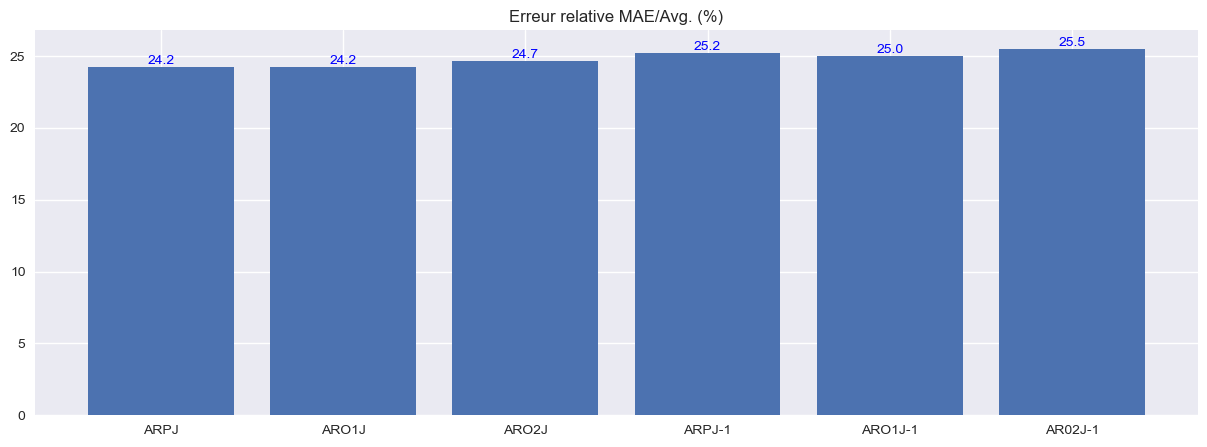

In [174]:
fig,ax = plt.subplots(figsize=(15,5))
abscisses = ["ARPJ","ARO1J","ARO2J","ARPJ-1","ARO1J-1","AR02J-1"]
bars = ax.bar(abscisses,tableau_mae_avg*100)
ax.bar_label(bars, label_type='edge', color='blue',fmt='%.1f')
ax.set_title("Erreur relative MAE/Avg. (%)")

### RMSE sur toute la période en fonction du modèle

In [175]:
capacite = 1000 #W/m2
N = len(df['GLOBAL'])
#rmse_clearsky = np.sqrt( np.sum((df['cGLOBAL']-df['GLOBAL'])**2) / N ) 

rmse_arp_J = np.sqrt( np.sum((df['GLO_ARP_J']-df['GLOBAL'])**2) / N )
rmse_aro1_J = np.sqrt( np.sum((df['GLO_ARO1_J']-df['GLOBAL'])**2) / N ) 
rmse_aro2_J = np.sqrt( np.sum((df['GLO_ARO2_J']-df['GLOBAL'])**2) / N ) 

rmse_arp_J1 = np.sqrt( np.sum((df['GLO_ARP_J1']-df['GLOBAL'])**2) / N ) 
rmse_aro1_J1 = np.sqrt( np.sum((df['GLO_ARO1_J1']-df['GLOBAL'])**2) / N ) 
rmse_aro2_J1 = np.sqrt( np.sum((df['GLO_ARO2_J1']-df['GLOBAL'])**2) / N ) 

tableau_rmse = np.array([rmse_arp_J,rmse_aro1_J,rmse_aro2_J,rmse_arp_J1,rmse_aro1_J1,rmse_aro2_J1])
tableau_rmse_capacity = tableau_rmse / capacite

Text(0.5, 1.0, 'Erreur relative RMSE/Capacity (%)')

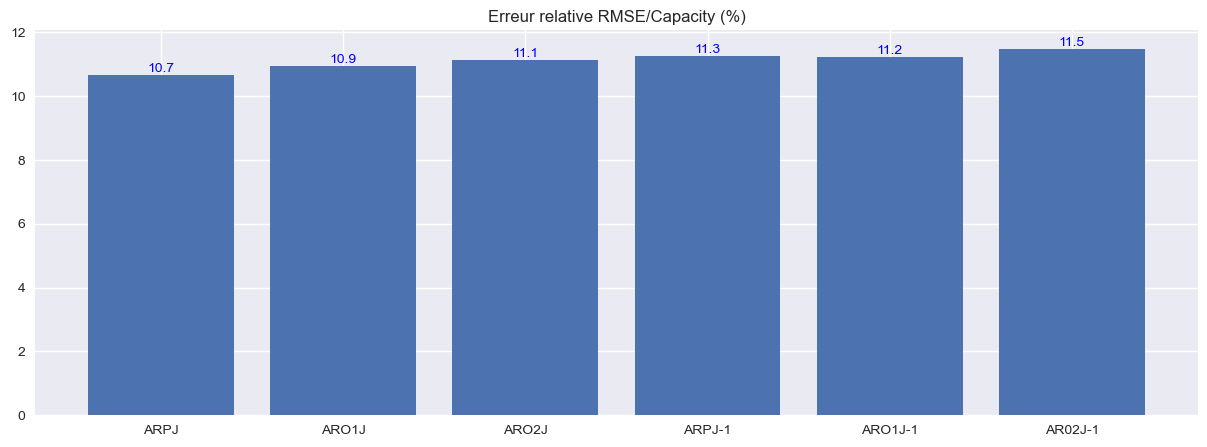

In [176]:
fig,ax = plt.subplots(figsize=(15,5))
bars = ax.bar(abscisses,tableau_rmse_capacity*100)
ax.bar_label(bars, label_type='edge', color='blue',fmt='%.1f')
ax.set_title("Erreur relative RMSE/Capacity (%)")

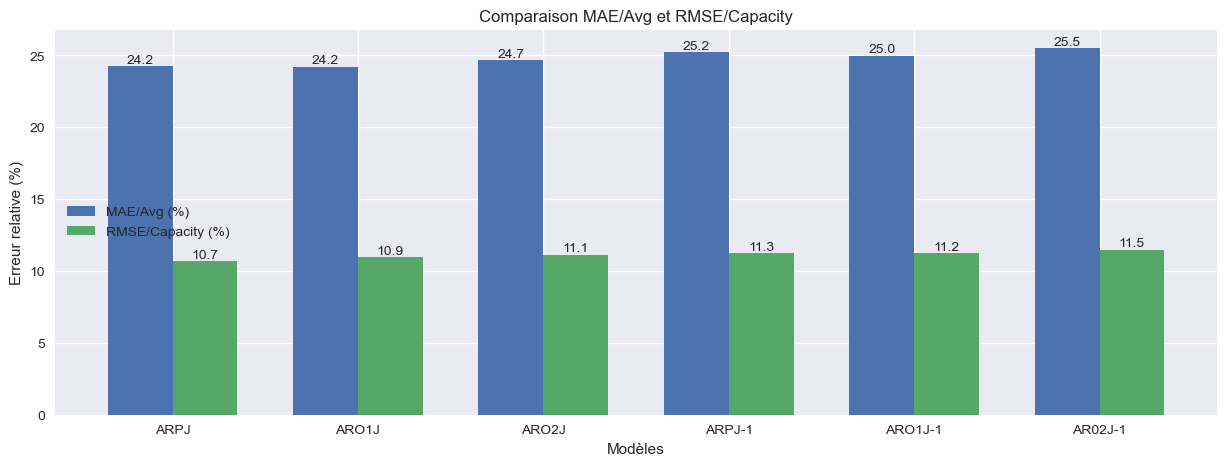

In [177]:
fig, ax = plt.subplots(figsize=(15, 5))

# Largeur des barres et espacement
x = np.arange(len(abscisses))
width = 0.35

# Créer les deux séries de barres
bars1 = ax.bar(x - width/2, tableau_mae_avg*100, width, 
                label='MAE/Avg (%)')
bars2 = ax.bar(x + width/2, tableau_rmse_capacity*100, width,
                label='RMSE/Capacity (%)')

# Ajouter les labels sur les barres
ax.bar_label(bars1, label_type='edge',fmt='%.1f')
ax.bar_label(bars2, label_type='edge',fmt='%.1f')

# Configuration du graphique
ax.set_xlabel('Modèles')
ax.set_ylabel('Erreur relative (%)')
ax.set_title('Comparaison MAE/Avg et RMSE/Capacity')
ax.set_xticks(x)
ax.set_xticklabels(abscisses)
ax.legend()
plt.show()


## Distinction selon le type de jour : ensoleillé, variable ou couvert

In [178]:
df['CSI']=df['GLOBAL']/df['cGLOBAL']


df['Date'] = df.index.date
moyenne_quotidienne_csi = df.groupby('Date')['CSI'].mean()
df['CSI_jour_moyen'] = df['Date'].map(moyenne_quotidienne_csi)


df['type_jour'] = 'ensoleille'
df.loc[df['CSI_jour_moyen'] <= 0.4, 'type_jour'] = 'couvert'
df.loc[(df['CSI_jour_moyen'] > 0.4) & (df['CSI_jour_moyen'] <= 0.8), 'type_jour'] = 'variable'

# Afficher les premières lignes pour vérifier
df[['Date','CSI', 'CSI_jour_moyen','type_jour']].head(100)

,Date,CSI,CSI_jour_moyen,type_jour
date,,,,
2015-10-17 06:00:00,2015-10-17,0.112554,0.329811,couvert
2015-10-17 07:00:00,2015-10-17,0.168823,0.329811,couvert
2015-10-17 08:00:00,2015-10-17,0.226662,0.329811,couvert
2015-10-17 09:00:00,2015-10-17,0.451243,0.329811,couvert
2015-10-17 10:00:00,2015-10-17,0.737990,0.329811,couvert
...,...,...,...,...
2015-10-26 13:00:00,2015-10-26,0.390067,0.478081,variable
2015-10-26 14:00:00,2015-10-26,0.927273,0.478081,variable
2015-10-26 15:00:00,2015-10-26,0.841954,0.478081,variable


### MAE/Avg. de ARPEGE J en fonction du type de jour
Métrique bien choisie car la valeur n'est pas fonction du nombre de mesures

In [179]:
df_couvert = df.loc[df['type_jour']=='couvert']
mae_avg_couvert = np.sum(np.abs(df_couvert['GLO_ARP_J'] - df_couvert['GLOBAL']))/np.sum(df_couvert['GLOBAL'])
mae_avg_couvert*100

np.float64(60.55506309820898)

In [180]:
df_variable = df.loc[df['type_jour']=='variable']
mae_avg_variable = np.sum(np.abs(df_variable['GLO_ARP_J'] - df_variable['GLOBAL']))/np.sum(df_variable['GLOBAL'])
mae_avg_variable*100

np.float64(34.516939361234776)

In [181]:
df_ensoleille = df.loc[df['type_jour']=='ensoleille']
mae_avg_ensoleille = np.sum(np.abs(df_ensoleille['GLO_ARP_J'] - df_ensoleille['GLOBAL']))/np.sum(df_ensoleille['GLOBAL'])
mae_avg_ensoleille*100

np.float64(13.033741082755688)

Text(0.5, 1.0, 'Erreur relative MAE/Avg. (%) en fonction du type de jour')

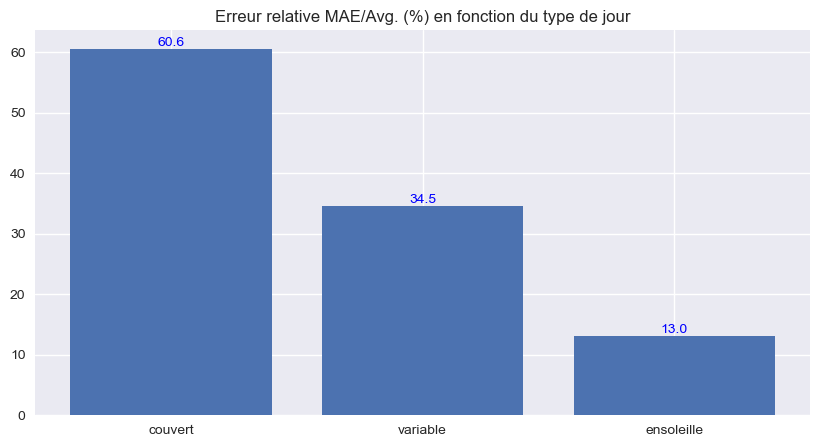

In [182]:
fig,ax = plt.subplots(figsize=(10,5))
bars = ax.bar(['couvert','variable','ensoleille'],[mae_avg_couvert*100,mae_avg_variable*100,mae_avg_ensoleille*100])
ax.bar_label(bars, label_type='edge', color='blue',fmt='%.1f')
ax.set_title("Erreur relative MAE/Avg. (%) en fonction du type de jour")

#### A faire : vérifier qu'on retrouve bien la valeur de MAE/Avg de ARPJ en faisant la moyenne pondérée/le calcul adéquat

#### Piste : tracer un nuage de points x = CSI_journalier_moyen y = MAE/AVG du jour

In [192]:
df.loc[df['CSI'] == np.inf,'CSI'] = np.nan
df_csi = df.loc[df['CSI']<1.3]

In [193]:
# Calculer la moyenne de GLOBAL par jour
average_par_jour = df_csi.groupby('Date')['GLOBAL'].mean()

# Calculer la somme absolue des erreurs (MAE) par jour
mae_par_jour = df_csi.groupby('Date').apply(lambda x: np.nansum(np.abs(x['GLO_ARP_J'] - x['GLOBAL'])))

# Calculer l'erreur relative MAE/Average par jour
erreur_relative = mae_par_jour / average_par_jour

/var/folders/xf/zzxt_7gs0f59w4vpftk6lq780000gn/T/ipykernel_2284/1791808030.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mae_par_jour = df_csi.groupby('Date').apply(lambda x: np.nansum(np.abs(x['GLO_ARP_J'] - x['GLOBAL'])))


In [194]:
# Extraire la moyenne de CSI par jour (déjà calculée)
moyenne_csi_par_jour = df_csi.groupby('Date')['CSI'].mean()

# Créer un DataFrame pour le nuage de points
resultats = pd.DataFrame({
    'CSI_jour_moyen': moyenne_csi_par_jour,
    'Erreur_relative': erreur_relative
}).reset_index()

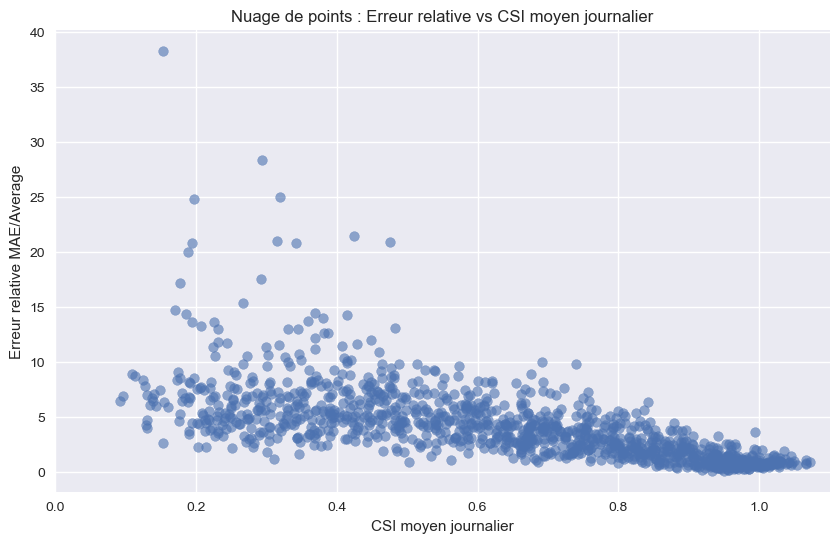

In [195]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(resultats['CSI_jour_moyen'], resultats['Erreur_relative'], alpha=0.6)
plt.xlabel('CSI moyen journalier')
plt.ylabel('Erreur relative MAE/Average')
plt.title('Nuage de points : Erreur relative vs CSI moyen journalier')
plt.grid(True)
plt.xlim((0,1.1))
plt.show()


In [196]:
# 1. Définir les tranches de CSI
n_bins = 30
bins = pd.cut(df_csi['CSI_jour_moyen'], bins=n_bins)

# 2. Regrouper les données par tranche de CSI
grouped = df_csi.groupby(bins)

# 3. Calculer la MAE et l'Average pour chaque tranche
mae_par_tranche = grouped.apply(lambda x: np.nansum(np.abs(x['GLO_ARP_J'] - x['GLOBAL'])))
average_par_tranche = grouped['GLOBAL'].sum()  # ou .mean() selon ce que tu veux comme "Average"

# 4. Calculer l'erreur relative MAE/Avg pour chaque tranche
erreur_relative_par_tranche = mae_par_tranche / average_par_tranche

# 5. Tracer le diagramme en barres
erreur_relative_par_tranche.plot(kind='bar', figsize=(12, 6), color='skyblue', edgecolor='black')
plt.xlabel('Tranche de CSI moyen journalier')
plt.ylabel('MAE/Avg par tranche de CSI')
plt.title(f'MAE/Avg par tranche de CSI ({n_bins} intervalles)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

ValueError: cannot specify integer `bins` when input data contains infinity

In [ ]:
df_csi[257:275].head(20)

,GLOBAL,cGLOBAL,GLO_ARO1_J,GLO_ARO2_J,GLO_ARP_J,GLO_ARO1_J1,GLO_ARO2_J1,GLO_ARP_J1,CSI,Date,CSI_jour_moyen,type_jour
date,,,,,,,,,,,,
2015-11-11 15:00:00,31.8,75.0,61.2,60.8,34.5,33.4,34.3,15.1,0.424000,2015-11-11,0.367404,couvert
2015-11-12 07:00:00,48.8,51.4,46.9,46.8,12.0,25.3,26.2,6.1,0.949416,2015-11-12,inf,ensoleille
2015-11-12 08:00:00,113.3,176.3,165.0,164.6,67.1,110.9,108.0,37.8,0.642655,2015-11-12,inf,ensoleille
2015-11-12 09:00:00,139.8,286.4,272.2,271.8,125.5,133.1,134.1,83.0,0.488128,2015-11-12,inf,ensoleille
2015-11-12 10:00:00,116.0,361.4,339.9,339.9,166.9,241.7,259.9,119.6,0.320974,2015-11-12,inf,ensoleille
2015-11-12 11:00:00,122.0,390.5,359.0,359.1,182.3,176.9,207.5,130.6,0.312420,2015-11-12,inf,ensoleille
2015-11-12 12:00:00,97.8,369.7,334.0,335.9,195.4,257.5,266.7,129.8,0.264539,2015-11-12,inf,ensoleille
2015-11-12 13:00:00,70.0,301.8,280.3,280.3,185.2,160.1,172.3,117.5,0.231942,2015-11-12,inf,ensoleille
2015-11-12 14:00:00,80.8,196.5,184.5,184.2,110.1,129.0,134.7,63.9,0.411196,2015-11-12,inf,ensoleille
